In [1]:
import nmrstarlib
from pybmrb import ChemicalShift
import pandas as pd
from pylab import *
import glob

In [2]:
# The bmrb ID for biris 2012 rhesus chemical shifts
bmrb_id = 18097

# Use pybmrb to fetch and parse the chemical shift data from bmrbm
bmrb_data = ChemicalShift.from_bmrb(bmrb_id)

a=list(bmrb_data[str(bmrb_id)+"-1"].values())[0]
a.pop("seq_ids") # we don't need the sequence IDs and it interferes with our easy conversion to a DF

#Convert the bmrb data to a dataframe
bmrbDF=pd.DataFrame.from_records(
    [
        (level1,level2, leaf)
        for level1, level2Dict in a.items()
        for level2, leaf in level2Dict.items()
        #for level3, leaf in level3Dict.items()
    ],
    columns=['resnum', 'atom',"TheList"]
)

# Unpack the list column in our dataframe
bmrbDF["resname"] = bmrbDF["TheList"].apply(lambda x: x[0])
bmrbDF["shift"] = bmrbDF["TheList"].apply(lambda x: x[-1])
bmrbDF["rescode"] = bmrbDF["TheList"].apply(lambda x: x[1])
bmrbDF["resid"] = bmrbDF['resnum'] +287 # The resnums appear to be 287 behind the resids.
bmrbDF["uniqueID"] = bmrbDF["resid"].astype(str) + bmrbDF["rescode"] + bmrbDF["atom"]

INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [3]:
testFile = pd.read_csv("shiftx/from-narval/s1_t0_f0.pdb.cs")
testFile['uniqueID'] = testFile.NUM.astype(str) + testFile.RES + testFile.ATOMNAME
testFile

,NUM,RES,ATOMNAME,SHIFT,uniqueID
0,290,E,C,177.5854,290EC
1,290,E,CA,59.3527,290ECA
2,290,E,CB,29.6186,290ECB
3,290,E,CD,182.5198,290ECD
4,290,E,CG,36.5211,290ECG
...,...,...,...,...,...
2490,493,P,HB3,1.8068,493PHB3
2491,493,P,HD2,2.9385,493PHD2
2492,493,P,HD3,3.0524,493PHD3
2493,493,P,HG2,1.6556,493PHG2


In [4]:
#allrhesus_csv = glob.glob("shiftx/from-narval/s1*.cs")
#all_shiftx_shifts=[]
#all_shiftx_dfs=[]
#all_uniqueIds=[]
#for i in range(len(allrhesus_csv)):
#    d = pd.read_csv(allrhesus_csv[i])
#    d['uniqueID'] = d.NUM.astype(str) + d.RES + d.ATOMNAME
#    uniqueIds+=list(d.uniqueID.values)
#    all_shiftx_dfs.append(d)
#    all_shiftx_shifts.append(d.SHIFT)
#unique_Ids=sorted(set(uniqueIds))

In [5]:
#combined_bmrb_andTestshiftx=bmrbHshifts.set_index('uniqueID').join(testHshifts.set_index('uniqueID'))
#combined_bmrb_andTestshiftx=combined_bmrb_andTestshiftx.dropna()
#combined_bmrb_andTestshiftx
#
#
#testHshifts=testFile[testFile["ATOMNAME"]=="H"]
#bmrbHshifts=bmrbDF[bmrbDF["atom"] == 'H']
#plot(bmrbHshifts.resid,bmrbHshifts['shift'],"o")
#plot(testHshifts.NUM,testHshifts['SHIFT'],"o")
#
#show()
#plot(combined_bmrb_andTestshiftx['shift'],combined_bmrb_andTestshiftx["SHIFT"],'o')
#ylabel("SHIFTX")
#xlabel("BMRB")

Text(0.5, 0, 'BMRB')

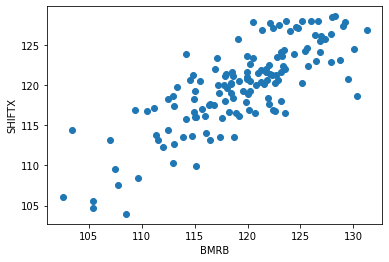

In [6]:

#OK, next, we need to apply this for all atoms.


combined_bmrb_andTestshiftx=bmrbDF.set_index('uniqueID').join(testFile.set_index('uniqueID'))
combined_bmrb_andTestshiftx=combined_bmrb_andTestshiftx.dropna()
combined_bmrb_andTestshiftx

show()
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],'o')
ylabel("SHIFTX")
xlabel("BMRB")

In [7]:
# Let's restore the NANs and set the SHIFTS column to 0, then loop over and add to the shifts
combined_bmrb_andTestshiftx=bmrbDF.set_index('uniqueID').join(testFile.set_index('uniqueID'))
combined_bmrb_andTestshiftx["SHIFT"] = 0

# we will also need a column to count the number of times a shift value was summed/meaned over, since it might not be the same number of times for each atom
combined_bmrb_andTestshiftx["NCOUNTED"] = 0 #Basically, if the column isnan() for each frame, we'll subtract that number off when taking the mean and stdev



allrhesus_csv = glob.glob("shiftx/from-narval/s1*.cs")
for i in range(len(allrhesus_csv)):
    
    # Read in data
    shiftxdf = pd.read_csv(allrhesus_csv[i])
    
    #First thing is to include the uniqueID
    shiftxdf['uniqueID'] = shiftxdf.NUM.astype(str) + shiftxdf.RES + shiftxdf.ATOMNAME
    
    #Next we left join the current frame onto the main frame to exclude all data that is not present in the BMRB
    currentFrameJoin=combined_bmrb_andTestshiftx.join(shiftxdf.set_index("uniqueID")["SHIFT"],rsuffix='new')
    
    # Increase the count of counted atoms - we are summing over shifts in each file, but we need to remember how many files we summed over for each atom
    combined_bmrb_andTestshiftx["NCOUNTED"]+=~combined_bmrb_andTestshiftx.join(shiftxdf.set_index("uniqueID")["SHIFT"],rsuffix='new').SHIFTnew.isna()
    
    #Add the shifts that we have to the "SHIFT" columnn
    combined_bmrb_andTestshiftx["SHIFT"]+=currentFrameJoin["SHIFTnew"].fillna(0)

# Once it is all done, we jsut need to divide the shifts by the NUMCOUNTED to get the mean shifts over frames
combined_bmrb_andTestshiftx["SHIFT"]/=combined_bmrb_andTestshiftx["NCOUNTED"]


combined_bmrb_andTestshiftx["SD"] = 0 #Basically, if the column isnan() for each frame, we'll subtract that number off when taking the mean and stdev


allrhesus_csv = glob.glob("shiftx/from-narval/s1*.cs")
for i in range(len(allrhesus_csv)):
    
    # Read in data
    shiftxdf = pd.read_csv(allrhesus_csv[i])
    
    #First thing is to include the uniqueID
    shiftxdf['uniqueID'] = shiftxdf.NUM.astype(str) + shiftxdf.RES + shiftxdf.ATOMNAME
    
    #Next we left join the current frame onto the main frame to exclude all data that is not present in the BMRB
    currentFrameJoin=combined_bmrb_andTestshiftx.join(shiftxdf.set_index("uniqueID")["SHIFT"],rsuffix='new')

    #Add the shifts that we have to the "SHIFT" columnn
    combined_bmrb_andTestshiftx["SD"]+=(currentFrameJoin["SHIFTnew"].fillna(0) - currentFrameJoin["SHIFT"])**2

combined_bmrb_andTestshiftx["SD"]/=combined_bmrb_andTestshiftx["NCOUNTED"]
combined_bmrb_andTestshiftx["SD"] = sqrt(combined_bmrb_andTestshiftx["SD"])
combined_bmrb_andTestshiftx["SEM"] = combined_bmrb_andTestshiftx["SD"] /(sqrt(9))

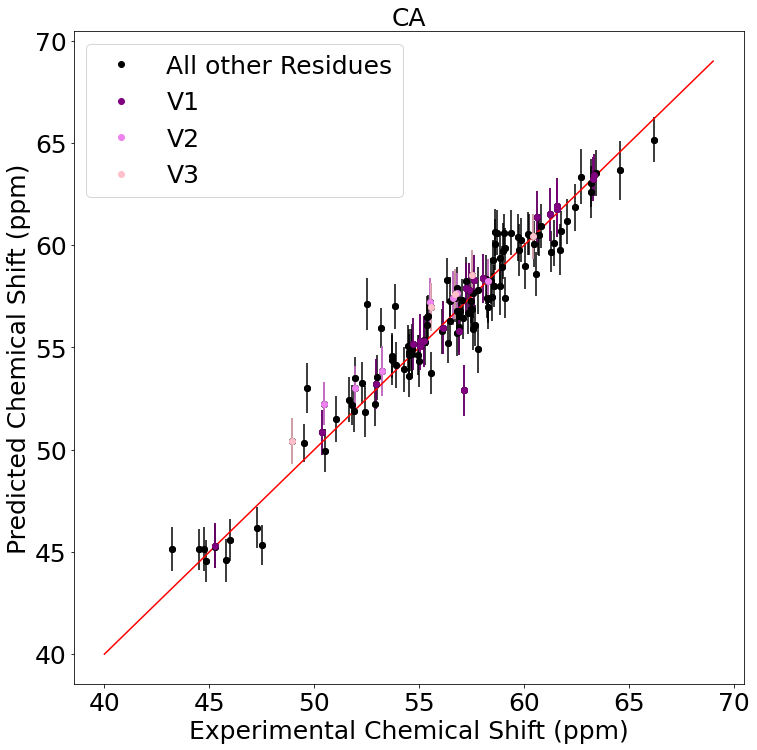

In [8]:
CASYSTEMATICERROR = 0.8743

figure(figsize = (12,12))

ylabel("Predicted Chemical Shift (ppm)",fontsize = 25)
xlabel("Experimental Chemical Shift (ppm)",fontsize = 25)
title('CA',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)


plot(arange(40,70),arange(40,70),color = 'red')

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")["SHIFT"],'o',color = 'black',label = 'All other Residues')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")["SHIFT"],yerr=CASYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")["SEM"],fmt="o",color = 'black')



plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")["SHIFT"],'o',color = 'purple',label = "V1")
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")["SHIFT"],yerr=CASYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")["SEM"],fmt="o",color = 'purple')

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")["SHIFT"],'o',color = 'violet',label = "V2")
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")["SHIFT"],yerr=CASYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")["SEM"],fmt="o",color = 'violet')

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")["SHIFT"],'o',color = 'pink',label = "V3")
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")["SHIFT"],yerr=CASYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")["SEM"],fmt="o",color = 'pink')


legend(fontsize = 25)
combined_bmrb_andTestshiftx.to_csv("combined_bmrb_andTestshiftx.csv")

0.8242206701555906 0.9138362704036361


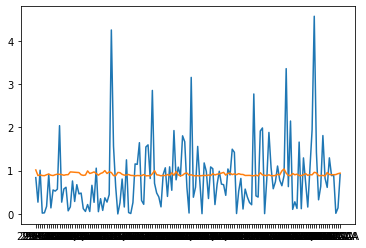

In [9]:
summed_err=mean(abs(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")['shift']-combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")["SHIFT"]))
summed_err_uncertainty=mean(sqrt((CASYSTEMATICERROR)**2 + (combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")["SEM"])**2))

print(summed_err,summed_err_uncertainty)
plot(abs(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")['shift']-combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")["SHIFT"]))
plot(sqrt((CASYSTEMATICERROR)**2 + (combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA'")["SEM"])**2))

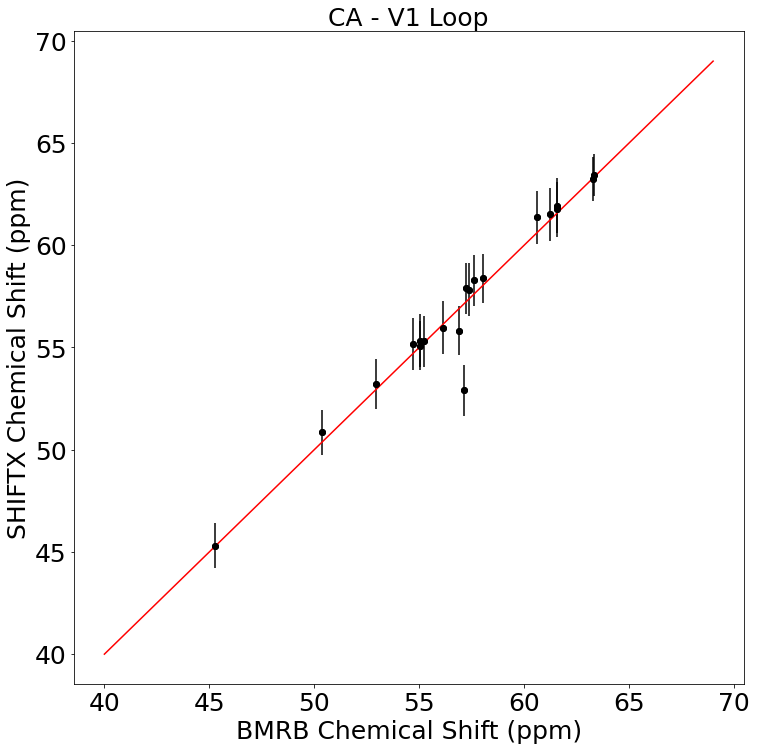

In [10]:
CASYSTEMATICERROR = 0.8743

figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")["SHIFT"],yerr=CASYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 325 and resid < 350")["SEM"],fmt="o",color = 'black')

ylabel("SHIFTX Chemical Shift (ppm)",fontsize = 25)
xlabel("BMRB Chemical Shift (ppm)",fontsize = 25)
title('CA - V1 Loop',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(40,70),arange(40,70),color = 'red')


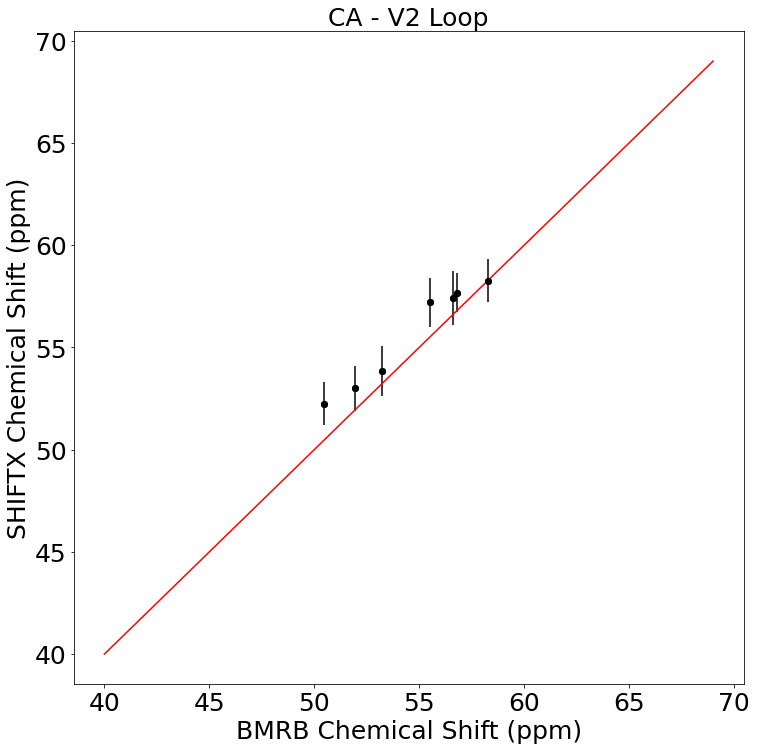

In [11]:
CASYSTEMATICERROR = 0.8743

figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")["SHIFT"],yerr=CASYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 380 and resid < 399")["SEM"],fmt="o",color = 'black')

ylabel("SHIFTX Chemical Shift (ppm)",fontsize = 25)
xlabel("BMRB Chemical Shift (ppm)",fontsize = 25)
title('CA - V2 Loop',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(40,70),arange(40,70),color = 'red')


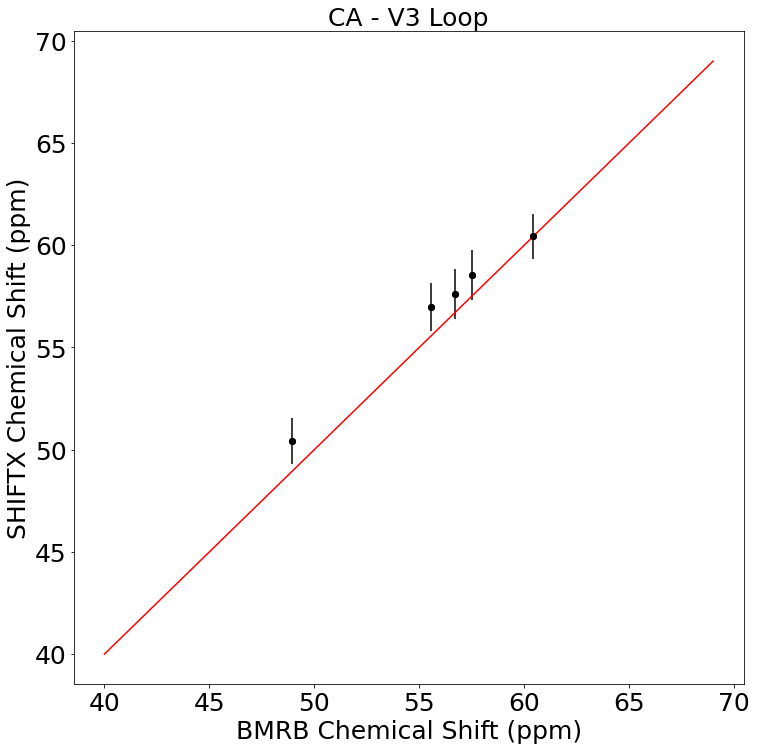

In [12]:
CASYSTEMATICERROR = 0.8743

figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")["SHIFT"],yerr=CASYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CA' and resid > 418 and resid < 429")["SEM"],fmt="o",color = 'black')

ylabel("SHIFTX Chemical Shift (ppm)",fontsize = 25)
xlabel("BMRB Chemical Shift (ppm)",fontsize = 25)
title('CA - V3 Loop',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(40,70),arange(40,70),color = 'red')


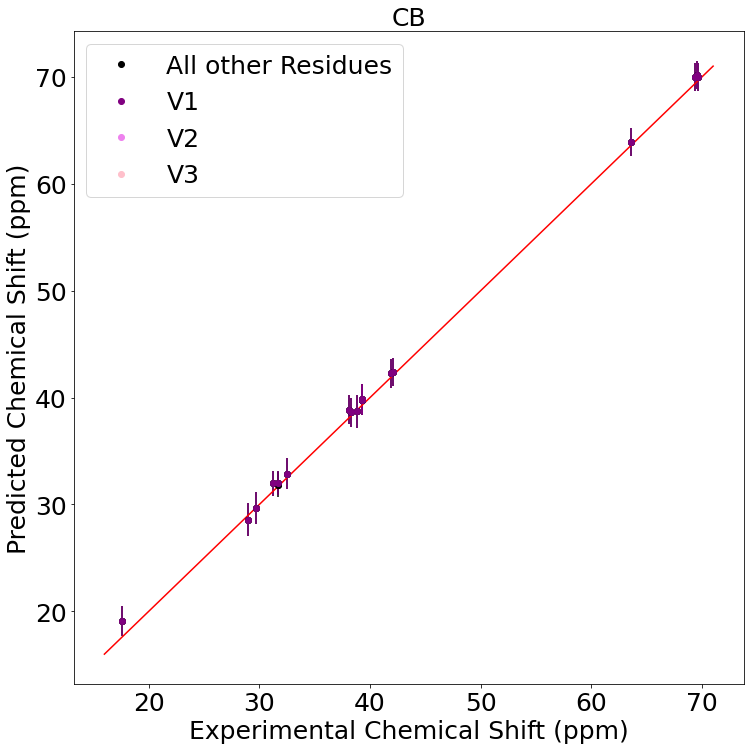

In [13]:
CBSYSTEMATICERROR = 1.0099

figure(figsize = (12,12))

ylabel("Predicted Chemical Shift (ppm)",fontsize = 25)
xlabel("Experimental Chemical Shift (ppm)",fontsize = 25)
title('CB',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)


plot(arange(16,72),arange(16,72),color = 'red')

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")["SHIFT"],'o',color = 'black',label = 'All other Residues')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")["SHIFT"],yerr=CBSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")["SEM"],fmt="o",color = 'black')

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")["SHIFT"],'o',color = 'purple',label = "V1")
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")["SHIFT"],yerr=CBSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")["SEM"],fmt="o",color = 'purple')

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")["SHIFT"],'o',color = 'violet',label = "V2")
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")["SHIFT"],yerr=CBSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")["SEM"],fmt="o",color = 'violet')

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")["SHIFT"],'o',color = 'pink',label = "V3")
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")["SHIFT"],yerr=CBSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")["SEM"],fmt="o",color = 'pink')


legend(fontsize = 25)




0.4679352627203883 1.071573159826911


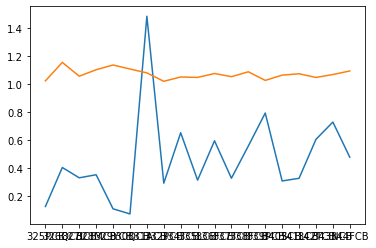

In [14]:
summed_err=mean(abs(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")['shift']-combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")["SHIFT"]))
summed_err_uncertainty=mean(sqrt((CBSYSTEMATICERROR)**2 + (combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")["SEM"])**2))

print(summed_err,summed_err_uncertainty)
plot(abs(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")['shift']-combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")["SHIFT"]))
plot(sqrt((CBSYSTEMATICERROR)**2 + (combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB'")["SEM"])**2))

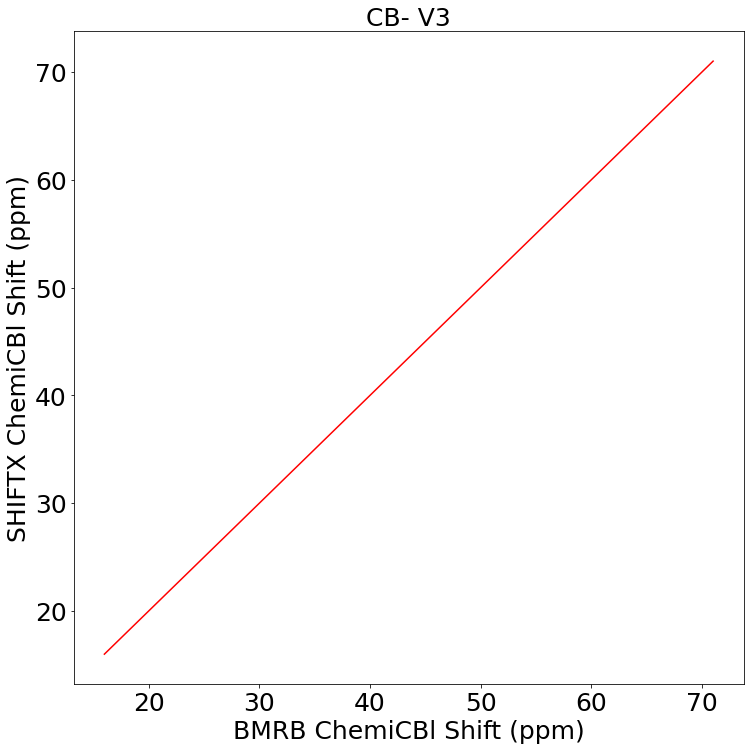

In [15]:
CBSYSTEMATICERROR = 1.0099


figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")["SHIFT"],yerr=CBSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 418 and resid < 429")["SEM"],fmt="o",color = 'black')

ylabel("SHIFTX ChemiCBl Shift (ppm)",fontsize = 25)
xlabel("BMRB ChemiCBl Shift (ppm)",fontsize = 25)
title('CB- V3',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(16,72),arange(16,72),color = 'red')




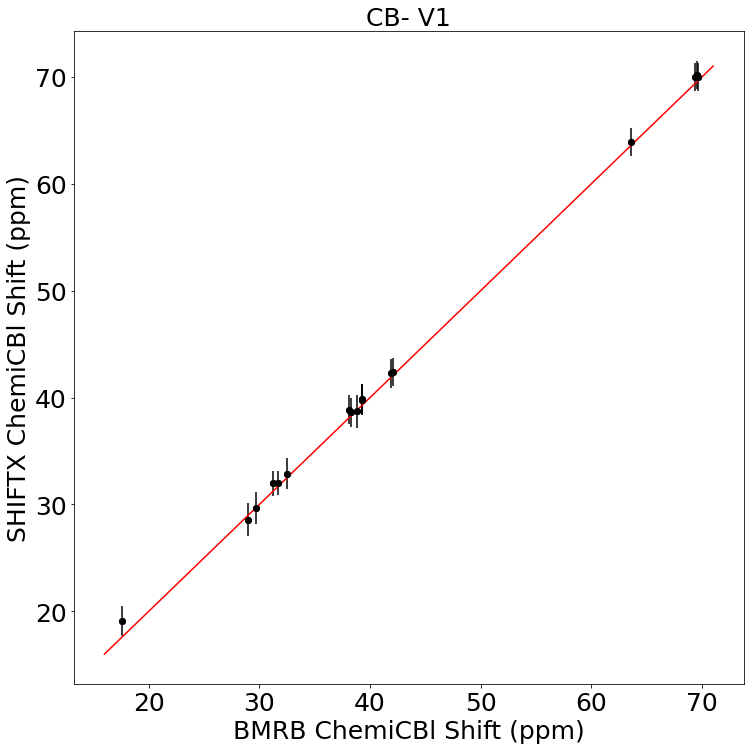

In [16]:
CBSYSTEMATICERROR = 1.0099


figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")["SHIFT"],yerr=CBSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 325 and resid < 350")["SEM"],fmt="o",color = 'black')

ylabel("SHIFTX ChemiCBl Shift (ppm)",fontsize = 25)
xlabel("BMRB ChemiCBl Shift (ppm)",fontsize = 25)
title('CB- V1',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(16,72),arange(16,72),color = 'red')




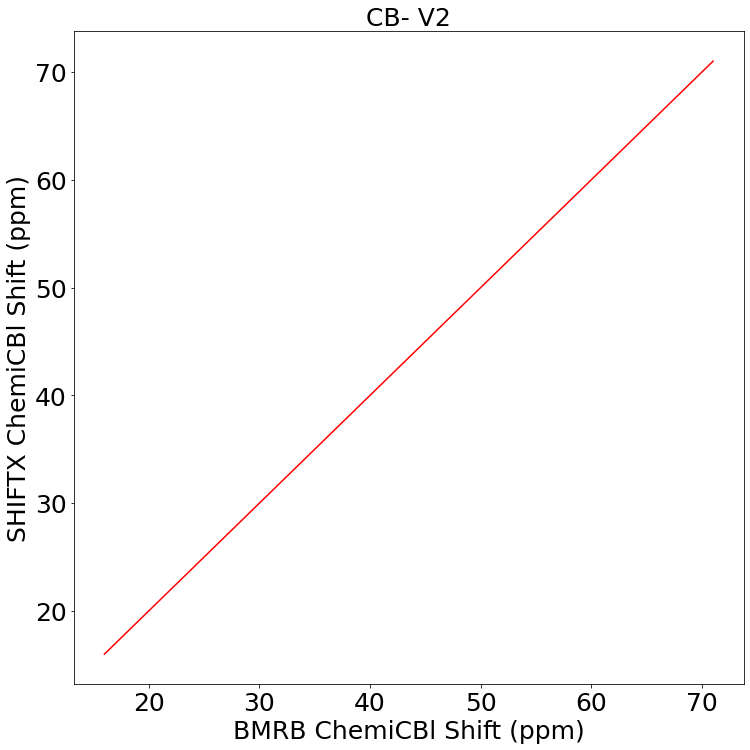

In [17]:
CBSYSTEMATICERROR = 1.0099


figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")["SHIFT"],yerr=CBSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'CB' and resid > 380 and resid < 399")["SEM"],fmt="o",color = 'black')

ylabel("SHIFTX ChemiCBl Shift (ppm)",fontsize = 25)
xlabel("BMRB ChemiCBl Shift (ppm)",fontsize = 25)
title('CB- V2',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(16,72),arange(16,72),color = 'red')




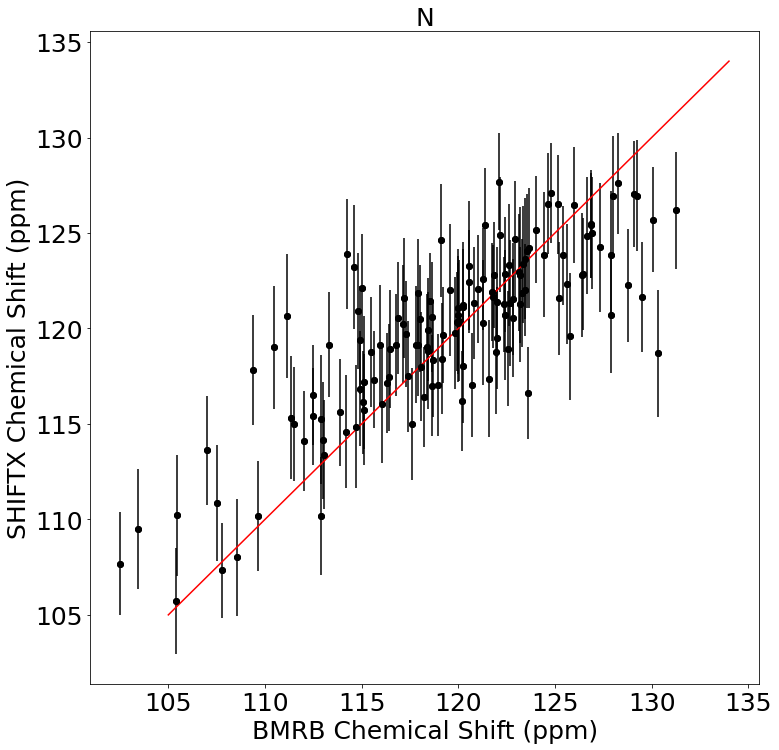

In [18]:
NSYSTEMATICERROR = 2.2878

figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],yerr=NSYSTEMATICERROR+combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SEM"],fmt="o",color = 'black')

ylabel("SHIFTX Chemical Shift (ppm)",fontsize = 25)
xlabel("BMRB Chemical Shift (ppm)",fontsize = 25)
title('N',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(105,135),arange(105,135),color = 'red')


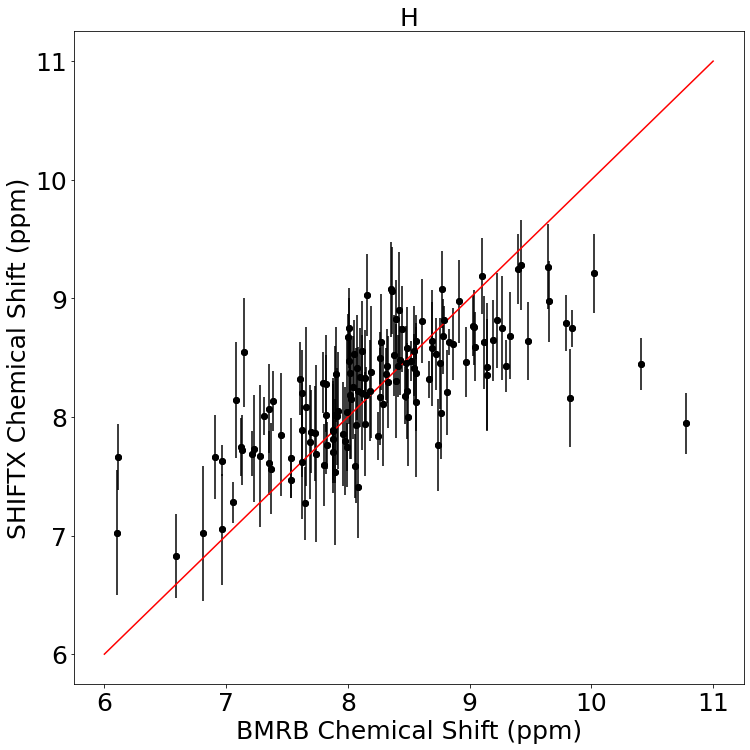

In [19]:
figure(figsize = (12,12,))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")["SHIFT"],yerr=combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")["SD"],fmt="o",color = 'black')

plot(arange(6,12),arange(6,12),color = 'red')
ylabel("SHIFTX Chemical Shift (ppm)",fontsize = 25)
xlabel("BMRB Chemical Shift (ppm)",fontsize = 25)
title('H',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)

Text(0, 0.5, 'Chemical Shifft (ppm)')

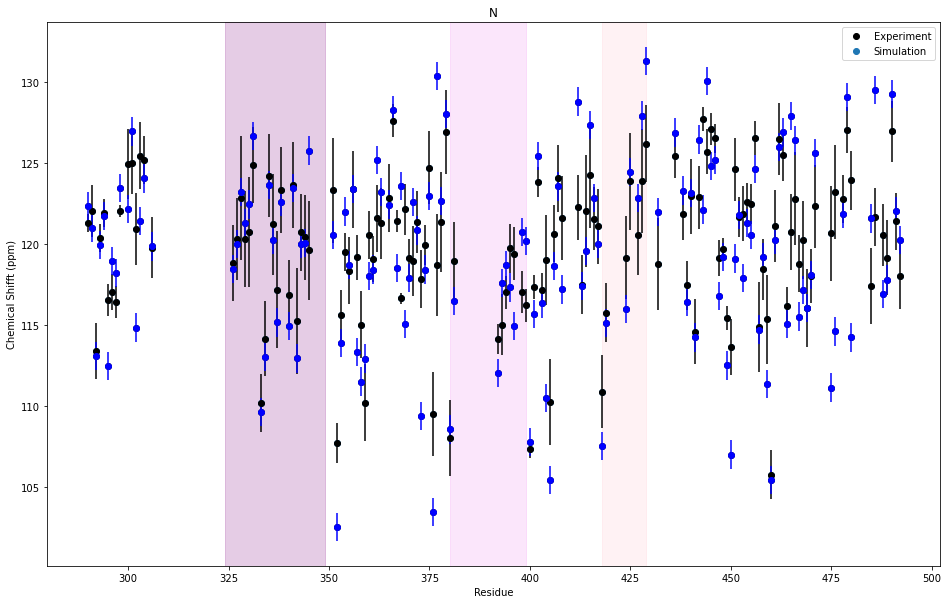

In [20]:
figure(figsize = (16,10))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],"o",color = 'black',label = "Experiment")
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['SHIFT'],"o",label = "Simulation")


errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['SHIFT'],yerr=combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SD"],fmt="o",color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],yerr=CASYSTEMATICERROR,fmt="o",color = 'blue')



#plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],alpha = 0.2,color = 'black')
#plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['SHIFT'],alpha = 0.2)
legend()


axvspan(324,349,color = "purple", alpha = 0.2)
axvspan(380,399,color = "violet", alpha = 0.2)
axvspan(418,429,color = "pink", alpha = 0.2)

title("N")
xlabel("Residue")
ylabel("Chemical Shifft (ppm)")

Text(0, 0.5, 'Chemical Shifft (ppm)')

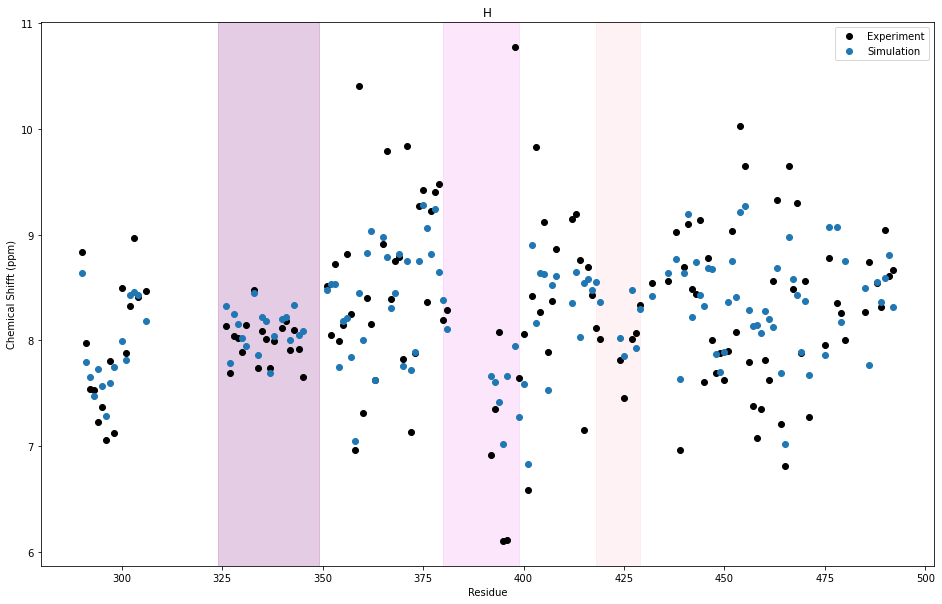

In [21]:
figure(figsize = (16,10))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],"o",color = 'black',label = "Experiment")
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['SHIFT'],"o",label = "Simulation")

#plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],alpha = 0.2,color = 'black')
#plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['SHIFT'],alpha = 0.2)
legend()


axvspan(324,349,color = "purple", alpha = 0.2)
axvspan(380,399,color = "violet", alpha = 0.2)
axvspan(418,429,color = "pink", alpha = 0.2)
        
title("H")
xlabel("Residue")
ylabel("Chemical Shifft (ppm)")